In [221]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT, RYGate
from qiskit.quantum_info import Statevector

def poisson_solver_qiskit(divergence, nx, ny, dx, dy):

    if nx != ny:
        raise ValueError(
            "This implementation currently requires nx == ny."
        )

    if nx < 2 or (nx & (nx - 1)):
        raise ValueError(
            "nx and ny must be powers of 2."
        )

    divergence_grid = np.asarray(
        divergence,
        dtype=float
    ).reshape(nx, ny)

    divergence_grid -= np.mean(divergence_grid)

    input_norm = np.linalg.norm(divergence_grid)

    if input_norm == 0:
        return np.zeros(nx * ny)

    divergence_normalised = (
        divergence_grid.ravel() / input_norm
    )

    n = int(np.log2(nx))

    n_spatial = 2 * n
    ancilla = n_spatial

    qc = QuantumCircuit(n_spatial + 1)

    qc.initialize(
        divergence_normalised,
        range(n_spatial)
    )

    qft = QFT(n)

    qc.append(
        qft,
        range(0, n)
    )

    qc.append(
        qft,
        range(n, 2 * n)
    )

    kx = (
        2 * np.pi
        * np.fft.fftfreq(nx, d=dx)
    )

    ky = (
        2 * np.pi
        * np.fft.fftfreq(ny, d=dy)
    )

    KX, KY = np.meshgrid(
        kx,
        ky,
        indexing="ij"
    )

    eigenvalues = -(KX**2 + KY**2)

    nonzero = np.abs(
        eigenvalues[eigenvalues != 0]
    )

    lambda_min = np.min(nonzero)

    C = lambda_min

    for ix in range(nx):

        for iy in range(ny):

            lam = eigenvalues[ix, iy]

            if np.isclose(lam, 0.0):
                continue

            ratio = C / abs(lam)

            ratio = min(ratio, 1.0)

            theta = -2.0 * np.arcsin(ratio)

            basis_index = ix + (iy << n)

            state_bits = format(
                basis_index,
                f"0{n_spatial}b"
            )

            rotation = RYGate(theta).control(
                n_spatial,
                ctrl_state=state_bits
            )

            qc.append(
                rotation,
                list(range(n_spatial))
                + [ancilla]
            )

    qc.append(
        qft.inverse(),
        range(0, n)
    )

    qc.append(
        qft.inverse(),
        range(n, 2 * n)
    )

    state = Statevector.from_instruction(qc)

    data = state.data

    solution = np.zeros(
        nx * ny,
        dtype=complex
    )

    for i in range(nx * ny):

        index = i + (1 << ancilla)

        solution[i] = data[index]

    solution = np.real(solution)

    solution -= np.mean(solution)

    solution *= input_norm / C

    return solution

/var/folders/dj/901mwm8s23x_zlv1zxqm8yd80000gn/T/ipykernel_64373/1259050276.py:8: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append( QFT(nx), range(0 , nx) )
/var/folders/dj/901mwm8s23x_zlv1zxqm8yd80000gn/T/ipykernel_64373/1259050276.py:9: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append( QFT(ny), range(nx, nx + ny))


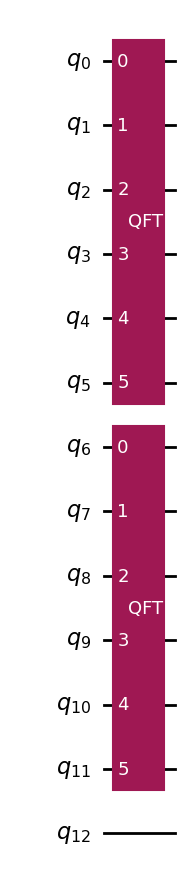

In [222]:

nx = 6
ny = 6

n_spatial = nx + ny

qc = QuantumCircuit(n_spatial + 1)

qc.append( QFT(nx), range(0 , nx) )
qc.append( QFT(ny), range(nx, nx + ny))

qc.draw("mpl")

In [223]:

import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse.linalg import spsolve
from scipy.interpolate import RegularGridInterpolator
from scipy.spatial import cKDTree

def vector_field_tree(scan_points, scan_normals, grid_points, sigma, cutoff_distance):

    V = np.zeros((len(grid_points), 2))
    tree = cKDTree(scan_points)

    for i, x in enumerate(grid_points):

        ids = tree.query_ball_point(x, cutoff_distance)

        for j in ids:
            p = scan_points[j]
            n = scan_normals[j]

            r2 = np.sum((x - p)**2)

            weight = np.exp(
                -r2 / (2 * sigma**2)
            )

            V[i] += weight * n

    return V

# First Order Finite difference
def calculate_gradient(Vx, Vy, dx, dy):

    # First-order finite difference
    dVx_dx = np.zeros_like(Vx)
    dVy_dy = np.zeros_like(Vy)

    # dVx/dx
    dVx_dx[:-1, :] = (Vx[1:, :] - Vx[:-1, :]) / dx
    dVx_dx[-1, :] = (Vx[-1, :] - Vx[-2, :]) / dx

    # dVy/dy
    dVy_dy[:, :-1] = (Vy[:, 1:] - Vy[:, :-1]) / dy
    dVy_dy[:, -1] = (Vy[:, -1] - Vy[:, -2]) / dy

    return dVx_dx, dVy_dy

def calculate_divergence(grid_vectors, nx, ny, dx, dy):

    Vx = grid_vectors[:, 0].reshape(nx, ny)
    Vy = grid_vectors[:, 1].reshape(nx, ny)
    
    dVx_dx = np.gradient(Vx, dx, axis=0)
    dVy_dy = np.gradient(Vy, dy, axis=1)

    """ dVx_dx, dVy_dy = calculate_gradient(Vx, Vy, dx, dy) """

    divergence = dVx_dx + dVy_dy

    return divergence.ravel()

def poisson_solver(divergence, nx, ny, dx, dy):

    divergence_grid = divergence.reshape(nx, ny)

    kx = 2 * np.pi * np.fft.fftfreq(nx, d=dx)
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=dy)

    KX, KY = np.meshgrid(kx, ky, indexing="ij")

    laplacian_eigenvalues = -(KX**2 + KY**2)

    divergence_hat = np.fft.fft2(divergence_grid)

    chi_hat = np.zeros_like(divergence_hat, dtype=complex)

    mask = laplacian_eigenvalues != 0

    chi_hat[mask] = ( divergence_hat[mask] / laplacian_eigenvalues[mask] )

    chi_hat[0, 0] = 0

    chi_grid = np.real(np.fft.ifft2(chi_hat))

    return chi_grid.ravel()

def surface_reconstruction(scan_points, scan_normals, size, nx, ny,):
    
    x = np.linspace(-size, size, nx)
    y = np.linspace(-size, size, ny)

    dx = x[1] - x[0]
    dy = y[1] - y[0]

    X, Y = np.meshgrid(x, y, indexing="ij")

    grid_points = np.column_stack( (X.ravel(), Y.ravel()) )

    sigma = 0.02
    D = 5 * sigma

    grid_vectors = vector_field_tree(scan_points, scan_normals, grid_points, sigma, D)

    divergence = calculate_divergence(grid_vectors, nx, ny, dx, dy)

    chi = poisson_solver(divergence, nx, ny, dx, dy)

    chi_grid = chi.reshape(nx, ny)

    interpolator = RegularGridInterpolator((x, y), chi_grid)

    chi_samples = interpolator(scan_points)

    iso_value = np.mean(chi_samples)

    return chi_grid, iso_value


In [224]:


def generate_square_wedge_points( n_per_side=20, n_per_wedge=15, size=1.0, ):

    points = []
    normals = []

    for x in np.linspace(-size, size, n_per_side, endpoint=False):
        points.append([x, -size])
        normals.append([0, -1])

    for y in np.linspace(-size, -0.3 * size, n_per_side, endpoint=False):
        points.append([size, y])
        normals.append([1, 0])

    p1 = np.array([size, -0.3 * size])
    p2 = np.array([0.0, 0.0])

    direction = p2 - p1
    length = np.linalg.norm(direction)

    normal = np.array([direction[1], -direction[0]]) / length

    for t in np.linspace(0, 1, n_per_wedge, endpoint=False):
        p = p1 + t * direction
        points.append(p)
        normals.append(normal)

    p1 = np.array([0.0, 0.0])
    p2 = np.array([size, 0.3 * size])

    direction = p2 - p1
    length = np.linalg.norm(direction)

    normal = np.array([direction[1], -direction[0]]) / length

    for t in np.linspace(0, 1, n_per_wedge, endpoint=False):
        p = p1 + t * direction
        points.append(p)
        normals.append(normal)

    for y in np.linspace(0.3 * size, size, n_per_side, endpoint=False):
        points.append([size, y])
        normals.append([1, 0])

    for x in np.linspace(size, -size, n_per_side, endpoint=False):
        points.append([x, size])
        normals.append([0, 1])

    for y in np.linspace(size, -size, n_per_side, endpoint=False):
        points.append([-size, y])
        normals.append([-1, 0])

    return np.array(points, dtype=float), np.array(normals, dtype=float)

def generate_circle_points(n=25):
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    points = np.column_stack((np.cos(angles), np.sin(angles)))
    normals = points.copy()

    return points, normals

def generate_square_points(n_per_side=25, size=1.0):
    scan_points = []
    scan_normals = []

    for x in np.linspace(-size, size, n_per_side, endpoint=False):
        scan_points.append([x, -size])
        scan_normals.append([0, -1])

    for y in np.linspace(-size, size, n_per_side, endpoint=False):
        scan_points.append([size, y])
        scan_normals.append([1, 0])

    for x in np.linspace(size, -size, n_per_side, endpoint=False):
        scan_points.append([x, size])
        scan_normals.append([0, 1])

    for y in np.linspace(size, -size, n_per_side, endpoint=False):
        scan_points.append([-size, y])
        scan_normals.append([-1, 0])

    scan_points = np.array(scan_points, dtype=float)
    scan_normals = np.array(scan_normals, dtype=float)

    return scan_points, scan_normals

def generate_circle_wedge_points( n_per_circle=50, n_per_wedge=15, radius=1.0, wedge_angle=np.pi / 3 ):

    points = []
    normals = []

    half_angle = wedge_angle / 2

    angles = np.linspace(
        half_angle,
        2 * np.pi - half_angle,
        n_per_circle,
        endpoint=False,
    )

    for theta in angles:

        p = radius * np.array([
            np.cos(theta),
            np.sin(theta),
        ])

        normal = p / radius

        points.append(p)
        normals.append(normal)

    theta = half_angle

    p1 = np.array([0.0, 0.0])

    p2 = radius * np.array([
        np.cos(theta),
        np.sin(theta),
    ])

    direction = p2 - p1

    normal = np.array([
        direction[1],
        -direction[0],
    ])

    normal /= np.linalg.norm(normal)

    for t in np.linspace(
        0,
        1,
        n_per_wedge,
        endpoint=False,
    ):

        p = p1 + t * direction

        points.append(p)
        normals.append(normal)

    theta = -half_angle

    p1 = np.array([0.0, 0.0])

    p2 = radius * np.array([
        np.cos(theta),
        np.sin(theta),
    ])

    direction = p2 - p1

    normal = np.array([
        -direction[1],
        direction[0],
    ])

    normal /= np.linalg.norm(normal)

    for t in np.linspace( 0, 1, n_per_wedge, endpoint=False ):

        p = p1 + t * direction

        points.append(p)
        normals.append(normal)

    return (
        np.array(points, dtype=float),
        np.array(normals, dtype=float),
    )


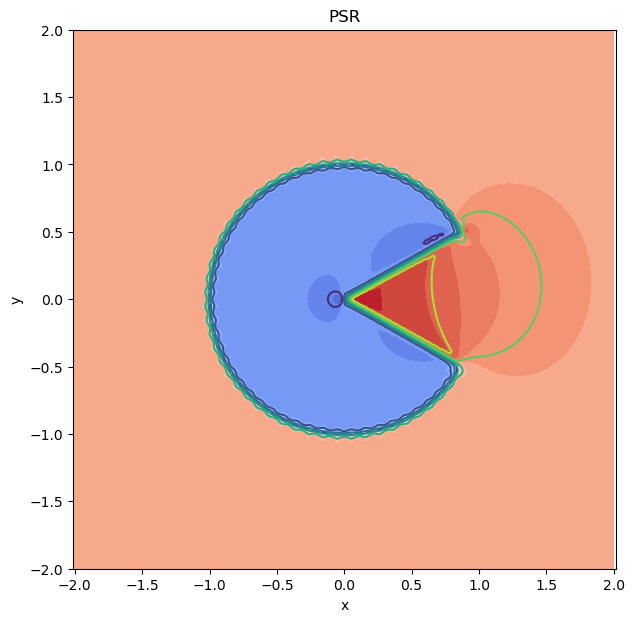

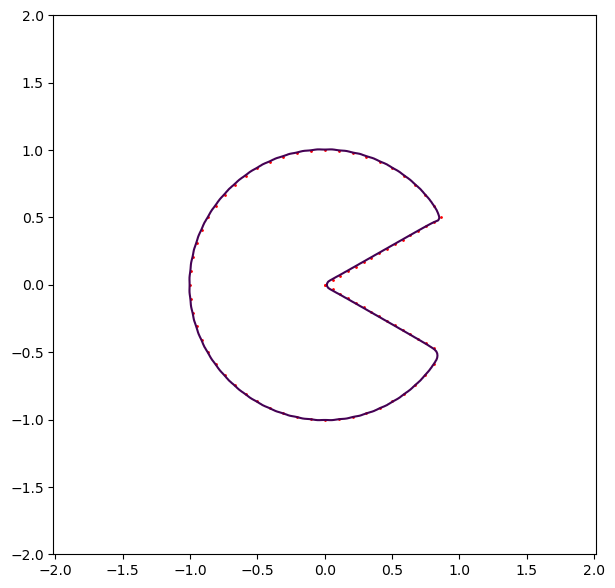

In [225]:

scan_points, scan_normals = generate_circle_wedge_points()

size = 2

nx = 256
ny = 256

x = np.linspace(-size, size, nx)
y = np.linspace(-size, size, ny)

X, Y = np.meshgrid(x, y, indexing="ij")

chi_grid, iso_value = surface_reconstruction(scan_points, scan_normals, size, nx, ny,)

plt.figure(figsize=(7, 7))

plt.contour(
    X,
    Y,
    chi_grid,
    levels=[iso_value],
    colors="blue"
)

#plt.scatter(
#    scan_points[:, 0],
#    scan_points[:, 1],
#    color="red",
#    s=50,
#    zorder=3
#)

#plt.quiver(
#    scan_points[:, 0],
#    scan_points[:, 1],    
#    scan_normals[:, 0],
#    scan_normals[:, 1],
#    color="black",
#    angles="xy",
#    scale_units="xy",
#    scale=1,
#    width=0.005,
#    zorder=4
#)

plt.contourf(X, Y, chi_grid, cmap="coolwarm", levels=20)
plt.contour(X, Y, chi_grid)

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("PSR")

plt.show()

fig, ax = plt.subplots(figsize=(7, 7))

contour = ax.contour(
    X,
    Y,
    chi_grid,
    levels=[iso_value]
)

ax.scatter(
    scan_points[:, 0],
    scan_points[:, 1],
    color="red",
    s=1,
    zorder=1
)

ax.axis("equal")
plt.show()

